In [1]:
library(ggplot2)
library(dtplyr)
library(tidyverse)
library(glue)
library(arrow)
library(patchwork)
library(data.table)
library("jsonlite")
library(ggthemes)
library(stringr)
library(ggtext)
library(ggdist)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.2 ──
✔ tibble  3.2.1     ✔ dplyr   1.1.0
✔ tidyr   1.3.0     ✔ stringr 1.5.0
✔ readr   2.1.3     ✔ forcats 1.0.0
✔ purrr   1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Attaching package: ‘arrow’


The following object is masked from ‘package:utils’:

    timestamp



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose



Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten




In [2]:
base_path = "/sc-projects/sc-proj-ukb-cvd/results/projects/22_medical_records/data/220823_allofus/230502_revision"
base_path

[1] "/sc-projects/sc-proj-ukb-cvd/results/projects/22_medical_records/data/220823_allofus/230502_revision"

In [3]:
base_size = 8
title_size = 10
facet_size = 9
geom_text_size=3
theme_set(theme_classic(base_size = base_size) +
          theme(strip.background = element_blank(), plot.title=element_text(size=title_size, hjust=0),
                strip.text.x = element_text(size = facet_size),axis.title=element_text(size=10), axis.text=element_text(size=8, color="black"),
                legend.position="bottom", axis.line = element_line(size = 0.2), axis.ticks=element_line(size=0.2), panel.grid.major.y=element_line()))

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


In [4]:
endpoint_defs = arrow::read_feather(glue("{base_path}/phecode_defs_220306.feather")) %>% arrange(endpoint)
endpoints_md = fread(glue("{base_path}/endpoints.csv"), colClasses=c("phecode"="character"))
endpoints = sort(endpoints_md$endpoint)

glue("{base_path}/phecode_defs_220306.feather")

/sc-projects/sc-proj-ukb-cvd/results/projects/22_medical_records/data/220823_allofus/230502_revision/phecode_defs_220306.feather

In [5]:
endpoint_map = endpoint_defs$phecode_string
names(endpoint_map) =  endpoint_defs$endpoint
endpoint_order = (endpoint_defs %>% arrange(as.numeric(phecode)))$endpoint

In [6]:
base_size = 8
title_size = 10
facet_size = 9
geom_text_size=3
theme_set(theme_classic(base_size = base_size) +
          theme(strip.background = element_blank(), plot.title=element_text(size=title_size, hjust=0),
                strip.text.x = element_text(size = facet_size),axis.title=element_text(size=10), axis.text=element_text(size=8, color="black"),
                legend.position="bottom", axis.line = element_line(size = 0.2), axis.ticks=element_line(size=0.2), panel.grid.major.y=element_line()))

In [7]:
endpoint_selection = c(

   'phecode_401', #  "Hypertension", # intervention
    'phecode_202', #  "Diabetes mellitus", # intervention
    'phecode_416-21', #  "Atrial fibrillation", # intervention
    'phecode_468', #  "Pneumonia", # intervention
    'phecode_474', #  "Chronic obstructive pulmonary disease [COPD]", # interventio
    'phecode_583', #  "Chronic kidney disease", # intervention

    'phecode_404', #  "Ischemic heart disease",
    'phecode_404-1', #  "Myocardial infarction [Heart attack]", # intervention
    'phecode_431-11', #  "Cerebral infarction [Ischemic stroke]",
    'phecode_424', #  "Heart failure", # intervention
    'phecode_420', #  "Cardiac arrest", # intervention
    'OMOP_4306655', #  "All-Cause Death", # intervention

    'phecode_438-11',   #  "Abdominal aortic aneurysm",
    'phecode_440-3',#  "Pulmonary embolism", # intervention
    'phecode_413-21',#  "Aortic stenosis", # intervention
    'phecode_413-11', #  "Mitral valve insufficiency",
    'phecode_410-2',#  "Endocarditis",
    'phecode_400',#  "Rheumatic fever and chronic rheumatic heart diseases",

    'phecode_164', #  "Anemia", # intervention
    'phecode_718',  #  "Back pain", # intervention
    'phecode_324-11', #  "Parkinson's disease (Primary)",
    'phecode_705-1', #  "Rheumatoid arthritis", # NEW + interventio
    'phecode_665', #  "Psoriasis", # interesting
    'phecode_284'#  "Suicide ideation and attempt or self harm" # intervention
)
endpoint_defs = endpoint_defs %>%
    mutate(name = phecode_string) %>%
    mutate(name =
           case_when(
               phecode_string == "Myocardial infarction [Heart attack]"~"Myocardial infarction",
               phecode_string == "Cerebral infarction [Ischemic stroke]"~"Ischemic stroke",
               phecode_string == "Chronic obstructive pulmonary disease [COPD]"~"COPD",
               phecode_string == "Mitral valve insufficiency"~"Mitral insufficiency",
               phecode_string == "Parkinson's disease (Primary)"~"Parkinson's",
               phecode_string == "Suicide ideation and attempt or self harm"~"Suicide attempt",
               phecode_string == "Ischemic heart disease"~"Ischemic HD",
               phecode_string == "Chronic kidney disease"~"Chronic KD",
               phecode_string == "Rheumatic fever and chronic rheumatic heart diseases"~"Rheumatic HD",
               phecode_string == "Abdominal aortic aneurysm"~"Abdominal AA",
                  TRUE ~ name)
           )

endpoint_map = endpoint_defs$name
names(endpoint_map) =  endpoint_defs$endpoint
#endpoint_order = (endpoint_defs %>% arrange(as.numeric(phecode)))$endpoint
endpoint_order = endpoint_selection

In [36]:
name = "230503_bootstrap_results_revision_ensemble"
benchmark_endpoints = arrow::read_feather(glue("{base_path}/{name}.feather"))

In [37]:
incident_events = read_csv(glue("{base_path}/../221011_incident_events.csv"))
incident_events = incident_events %>% rename(endpoint = "...1")
incident_events = setDT(incident_events)[, endpoint := str_replace(endpoint, "\\.", "-")] %>% as_tibble()

New names:
• `` -> `...1`
Rows: 1883 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): ...1
dbl (1): num_incident_events

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [38]:
benchmark_endpoints = benchmark_endpoints %>% group_by(endpoint, uuid) %>% filter(all(!is.na(cindex))) %>% ungroup()
benchmark_endpoints = setDT(benchmark_endpoints)[, endpoint := str_replace(endpoint, "\\.", "-")] %>% as_tibble()
benchmark_endpoints = benchmark_endpoints %>% left_join(endpoints_md) %>% left_join(incident_events, by='endpoint') %>% filter(num_incident_events >= 100)

Joining with `by = join_by(endpoint)`


In [40]:
endpoints_sorted = (benchmark_endpoints %>%
    filter(score == "AgeSex+MedicalHistory_UKBBParams") %>%
    group_by(endpoint, score) %>%
    summarise(cindex=mean(cindex, na.rm=TRUE)) %>%
    arrange(cindex) %>% ungroup())$endpoint

`summarise()` has grouped output by 'endpoint'. You can override using the
`.groups` argument.


In [41]:
categories_sorted = (endpoint_defs %>% distinct(phecode_category))$phecode_category

In [42]:
plot_width = 8.25; plot_height=2.5; plot_res = 600

In [43]:
plot_width = 8.25; plot_height=2.5; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

library(ggtext)
library(ggdist)

scores_plot = c("AgeSex_AoUCPH", "AgeSex+MedicalHistory_UKBBParams")

temp = benchmark_endpoints %>%
    filter(score %in% scores_plot) %>%
    mutate(score = factor(score, levels=scores_plot)) %>%
    mutate(endpoint = factor(endpoint, levels=endpoints_sorted)) %>%
    ungroup() %>%
    pivot_wider(names_from=score, values_from=cindex, id_cols=c(uuid, partition, endpoint, phecode_category, phecode_string)) %>%
    mutate(id = row_number()) %>%
    rename(score1 = scores_plot[1], score2 = scores_plot[2]) %>%
    mutate(delta=score2 - score1) %>%
    group_by(endpoint, phecode_string, phecode_category) %>%
    median_qi(delta) %>%
    #mutate(pos = case_when(delta>=0 ~ "pos", delta < 0 ~"neg")) %>%
    mutate(endpoint = fct_reorder(endpoint, delta)) %>%
    mutate(highlight = case_when(endpoint %in% endpoint_selection ~ "YES", TRUE ~ "NO")) %>%# %>% filter(endpoint %in% endpoint_sample)
    mutate(phecode_category = factor(phecode_category, levels=categories_sorted))

In [44]:
endpoint_order = (temp %>% arrange(delta))$endpoint

temp = temp %>% mutate(endpoint = factor(endpoint, levels=endpoint_order)) %>% ungroup() %>%
    arrange(endpoint) %>% group_by(phecode_category) %>% mutate(endpoint = row_number()) %>%
    filter(!phecode_category %in% c("Signs/Symptoms", "Preg", "Rx", "Stat"))

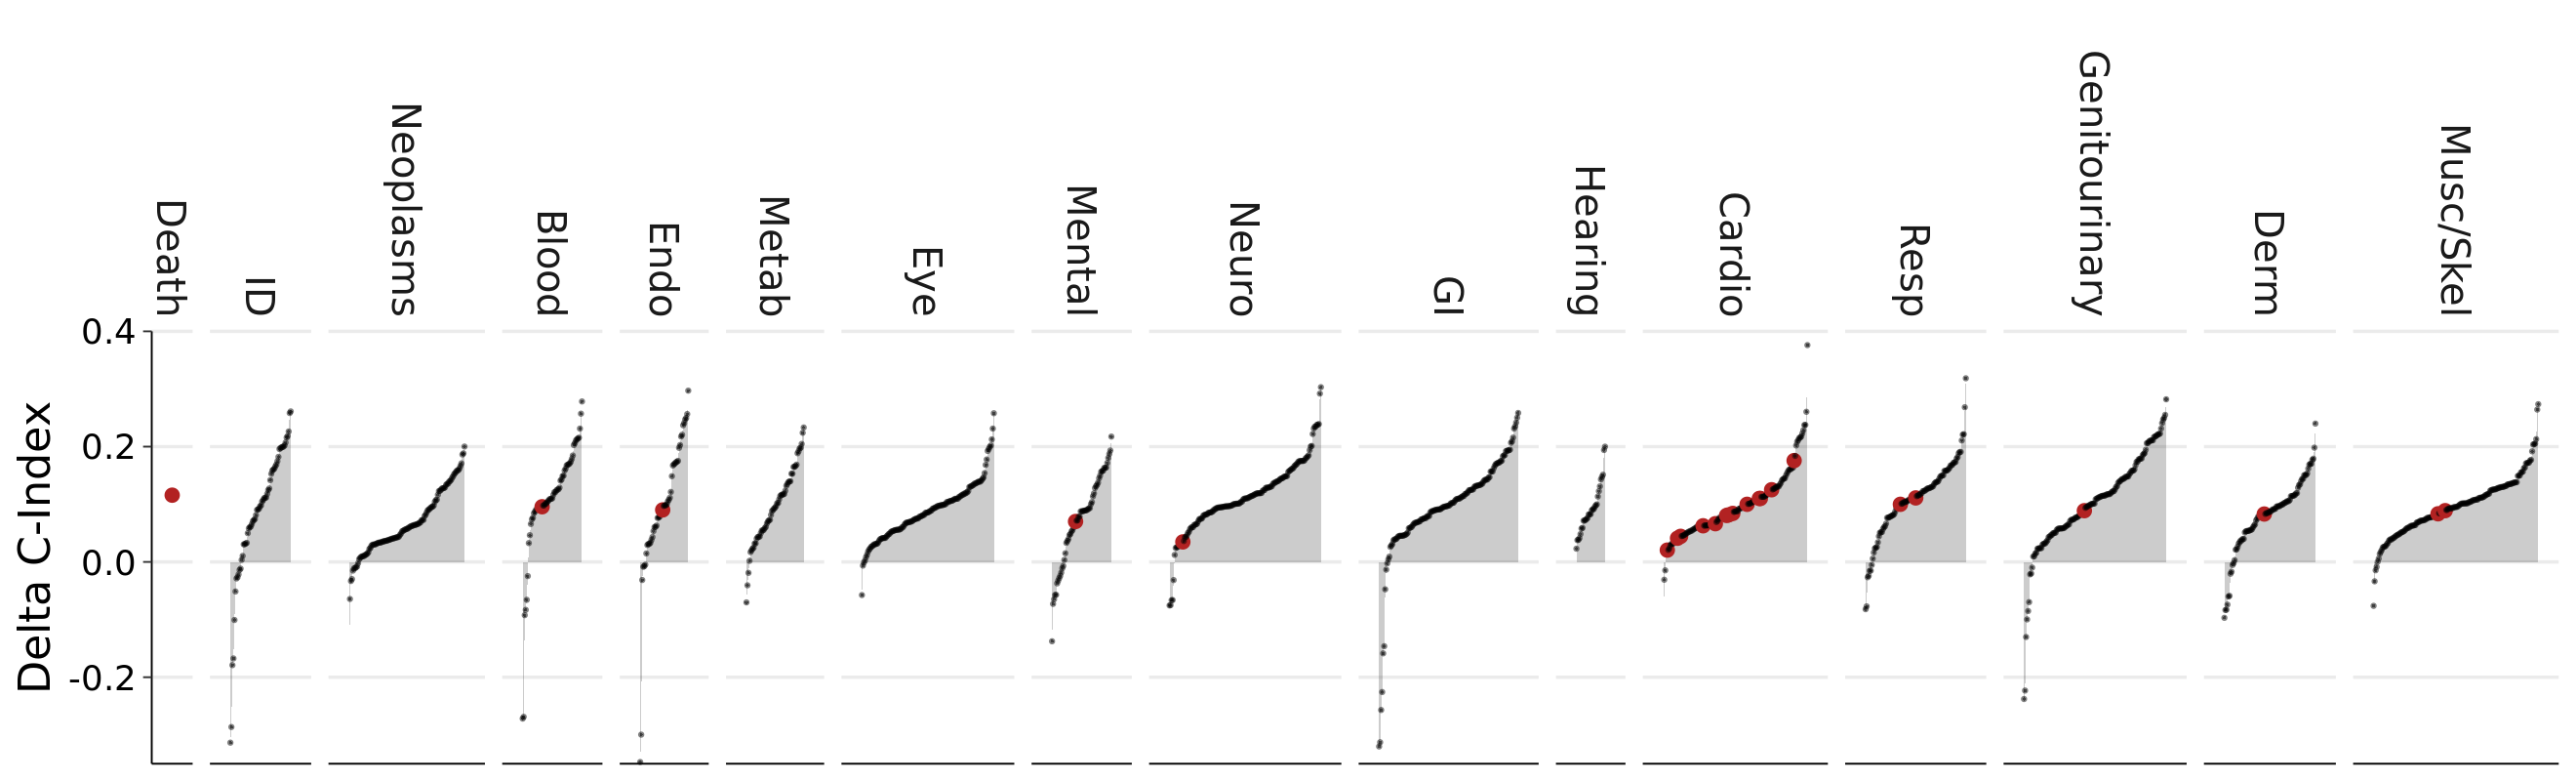

In [45]:
overview = ggplot(temp) +
    geom_ribbon(aes(x=endpoint, ymin=0, ymax=delta), fill="black", alpha=0.2)+
    geom_point(aes(x=endpoint, y=delta, color=highlight, size=highlight, alpha=highlight)) +
    #geom_text(data=temp %>% filter(highlight=="YES"), aes(x=endpoint, y=delta+0.045, label="↓"), color="black", size=5, alpha=0.7) +
    #geom_segment(aes(x=endpoint, xend=endpoint, y=0, yend=delta, color=highlight, size=highlight), alpha=0.5)+#+
    labs(x="Endpoints", y="Delta C-Index")+
    scale_color_manual(values=c("NO"="black", "YES"="firebrick"))+
    scale_alpha_manual(values=c("NO"=0.5, "YES"=1))+
    scale_size_manual(values=c("NO"=0.01, "YES"=1))+
    #scale_colour_manual(values = c("pos"="forestgreen", "neg" = "firebrick")) + 
    #coord_polar() +
    coord_cartesian(ylim=c(-0.35, 0.4), clip = "off")+
    scale_y_continuous(expand=c(0, 0))+
    scale_x_discrete(expand=expansion(add=20))+
    facet_grid(~phecode_category, scales="free_x", space="free_x")+#, switch=TRUE)+
    #facet_grid2(~phecode_category, scales = "free", independent = "all") + 
    theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
        panel.grid.major=element_blank(), 
         strip.text = element_text(angle=270, hjust=1)) + 
    theme(legend.position="none") 

overview

In [51]:
#library(gt)
plot_name = "Figure4a_AoU_Overview"
overview %>% ggsave(filename=glue("outputs/{plot_name}.png"), device="png", width=plot_width, height=plot_height, dpi=plot_res)
overview %>% ggsave(filename=glue("outputs/{plot_name}.pdf"), device="pdf", width=plot_width, height=plot_height, dpi=plot_res)

In [47]:
base_size = 8
title_size = 10
facet_size = 9
geom_text_size=3
theme_set(theme_classic(base_size = base_size) +
          theme(strip.background = element_blank(), plot.title=element_text(size=title_size, hjust=0),
                strip.text.x = element_text(size = facet_size),axis.title=element_text(size=10), axis.text=element_text(size=8, color="black"),
                legend.position="bottom", axis.line = element_line(size = 0.2), axis.ticks=element_line(size=0.2), panel.grid.major=element_line()))

In [48]:
plot_width = 8.25; plot_height=2; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

plot_against_score = function(score1, score2, endpoint_order=c()){

  scores_plot = c(score1, score2)#, "AgeSexMedicalHistory"

  score_label = glue("{score1} vs. {score2}")
  #print(score_label)

  temp = benchmark_endpoints %>%
      filter(score %in% scores_plot) %>%
      filter(endpoint %in% endpoint_selection) %>%
      mutate(score = factor(score, levels=scores_plot)) %>%
      mutate(endpoint = factor(endpoint, levels=sort(endpoint_selection))) %>%
      group_by(endpoint, score, phecode_string, phecode_category) %>%
      ungroup() %>%
      pivot_wider(names_from=score, values_from=cindex, id_cols=c(uuid, partition, endpoint, phecode_category, phecode_string)) %>%
      mutate(id = row_number()) %>%
      mutate(delta = !!sym(score2)-!!sym(score1)) %>%
      mutate(pos = case_when(delta>=0 ~ "pos", delta < 0 ~"neg")) %>%
      mutate(endpoint = fct_reorder(endpoint, delta)) %>%
      mutate(highlight = case_when(endpoint %in% endpoint_selection ~ "YES", TRUE ~ "NO")) %>%# %>% filter(endpoint %in% endpoint_sample)
      mutate(phecode_category = factor(phecode_category, levels=categories_sorted)) %>%
      filter(endpoint %in% endpoint_selection) #%>% mutate(endpoint=factor(endpoint, levels=endpoint_order_diff))

  temp_abs = temp %>% group_by(endpoint) %>% summarise(delta=median(delta), m_score2=median(!!sym(score2)), m_score1=median(!!sym(score1))) %>% ungroup()
  #print(levels(temp_abs$endpoint))

  temp_abs_segment = temp_abs %>% rowwise() %>% mutate(min_cindex = min(m_score1, m_score2), max_cindex=max(m_score1, m_score2)) %>% ungroup()# %>% filter(abs(min_cindex-max_cindex)>0.02)

  endpoint_order = (temp %>% group_by(endpoint) %>% summarise(delta=median(delta)) %>% arrange(delta))$endpoint
  print(endpoint_order)

  if (length(endpoint_order)>0){
      temp = temp %>% filter(endpoint %in% endpoint_order) %>% mutate(endpoint=factor(endpoint, levels=endpoint_order))
      temp_abs = temp_abs %>% filter(endpoint %in% endpoint_order) %>% mutate(endpoint=factor(endpoint, levels=endpoint_order))
      temp_abs_segment = temp_abs_segment %>% filter(endpoint %in% endpoint_order) %>% mutate(endpoint=factor(endpoint, levels=endpoint_order))
      }
  #print(temp_abs_segment)

  abs = ggplot(temp_abs) +
      #geom_violin(aes(x=fct_rev(endpoint), y=delta), size=0.5) +
      labs(y="Concordance Index")+

      #geom_segment(data=temp_abs_segment, mapping=aes(x=endpoint, xend=endpoint, y=min_cindex+0.01, yend=max_cindex-0.01), alpha=0.4)+#, arrow = arrow(length = unit(0.01, "npc")), arrow.fill="black")+#+


      geom_point(aes(x=fct_rev(endpoint), y=m_score1), size=1, color="black", alpha=0.7)+
      #geom_point(aes(x=fct_rev(endpoint), y=m_asm), size=1, color="#023768", alpha=0.7)+
      geom_point(aes(x=fct_rev(endpoint), y=m_score2), size=1.5, color="firebrick", alpha=0.7)+
      geom_segment(data=temp_abs %>% filter(abs(delta)>0.02) %>% mutate(endpoint=factor(endpoint, levels=endpoint_order)),
                   aes(x=fct_rev(endpoint), xend=fct_rev(endpoint), y=m_score1+0.01, yend=m_score2-0.01), alpha=0.2, arrow = arrow(length = unit(0.01, "npc")), arrow.fill="black")+#,

      scale_x_discrete(labels=endpoint_map) +

      coord_flip(ylim=c(0.5, 0.9))+
       theme(strip.text = element_text(angle=270), axis.title.y=element_blank()) +
      theme(legend.position="none")

      #geom_ribbon(aes(x=id, ymin=AgeSex, ymax=`Age+Sex+MedicalHistory`), fill="red", alpha=0.2)
  #geom_violin(size=0.1)
  rel = ggplot(temp) +
      #geom_violin(aes(x=fct_rev(endpoint), y=delta), size=0.5) +
      labs(y="Difference in Concordance Index")+
      geom_hline(yintercept=0, size=0.25, alpha=0.5, linetype="22") +
      stat_pointinterval(aes(x=fct_rev(endpoint), y=delta), size=0.5, alpha=0.7)+

      theme(axis.title.y=element_blank(),
          axis.text.y=element_blank(),
         axis.ticks.y=element_blank()) +
      coord_flip(ylim=c(-0.01, 0.23))+
       theme(strip.text = element_text(angle=270)) +
      theme(legend.position="none")

      #geom_ribbon(aes(x=id, ymin=AgeSex, ymax=`Age+Sex+MedicalHistory`), fill="red", alpha=0.2)
  #geom_violin(size=0.1)
  return(abs|rel)
}

In [49]:
ase_size = 8
title_size = 10
facet_size = 9
geom_text_size=3
theme_set(theme_classic(base_size = base_size) +
          theme(strip.background = element_blank(), plot.title=element_text(size=title_size, hjust=0),
                strip.text.x = element_text(size = facet_size),axis.title=element_text(size=10), axis.text=element_text(size=8, color="black"),
                legend.position="bottom", axis.line = element_line(size = 0.2), axis.ticks=element_line(size=0.2), panel.grid.major=element_line()))

endpoint_order=c()
length(endpoint_order)

[1] 0

 [1] phecode_401    phecode_324-11 phecode_438-11 phecode_416-21 phecode_404   
 [6] phecode_410-2  phecode_284    phecode_400    phecode_431-11 phecode_665   
[11] phecode_718    phecode_413-21 phecode_583    phecode_705-1  phecode_202   
[16] phecode_164    phecode_474    phecode_413-11 phecode_404-1  phecode_424   
[21] phecode_468    OMOP_4306655   phecode_440-3  phecode_420   
24 Levels: phecode_401 phecode_324-11 phecode_438-11 ... phecode_420


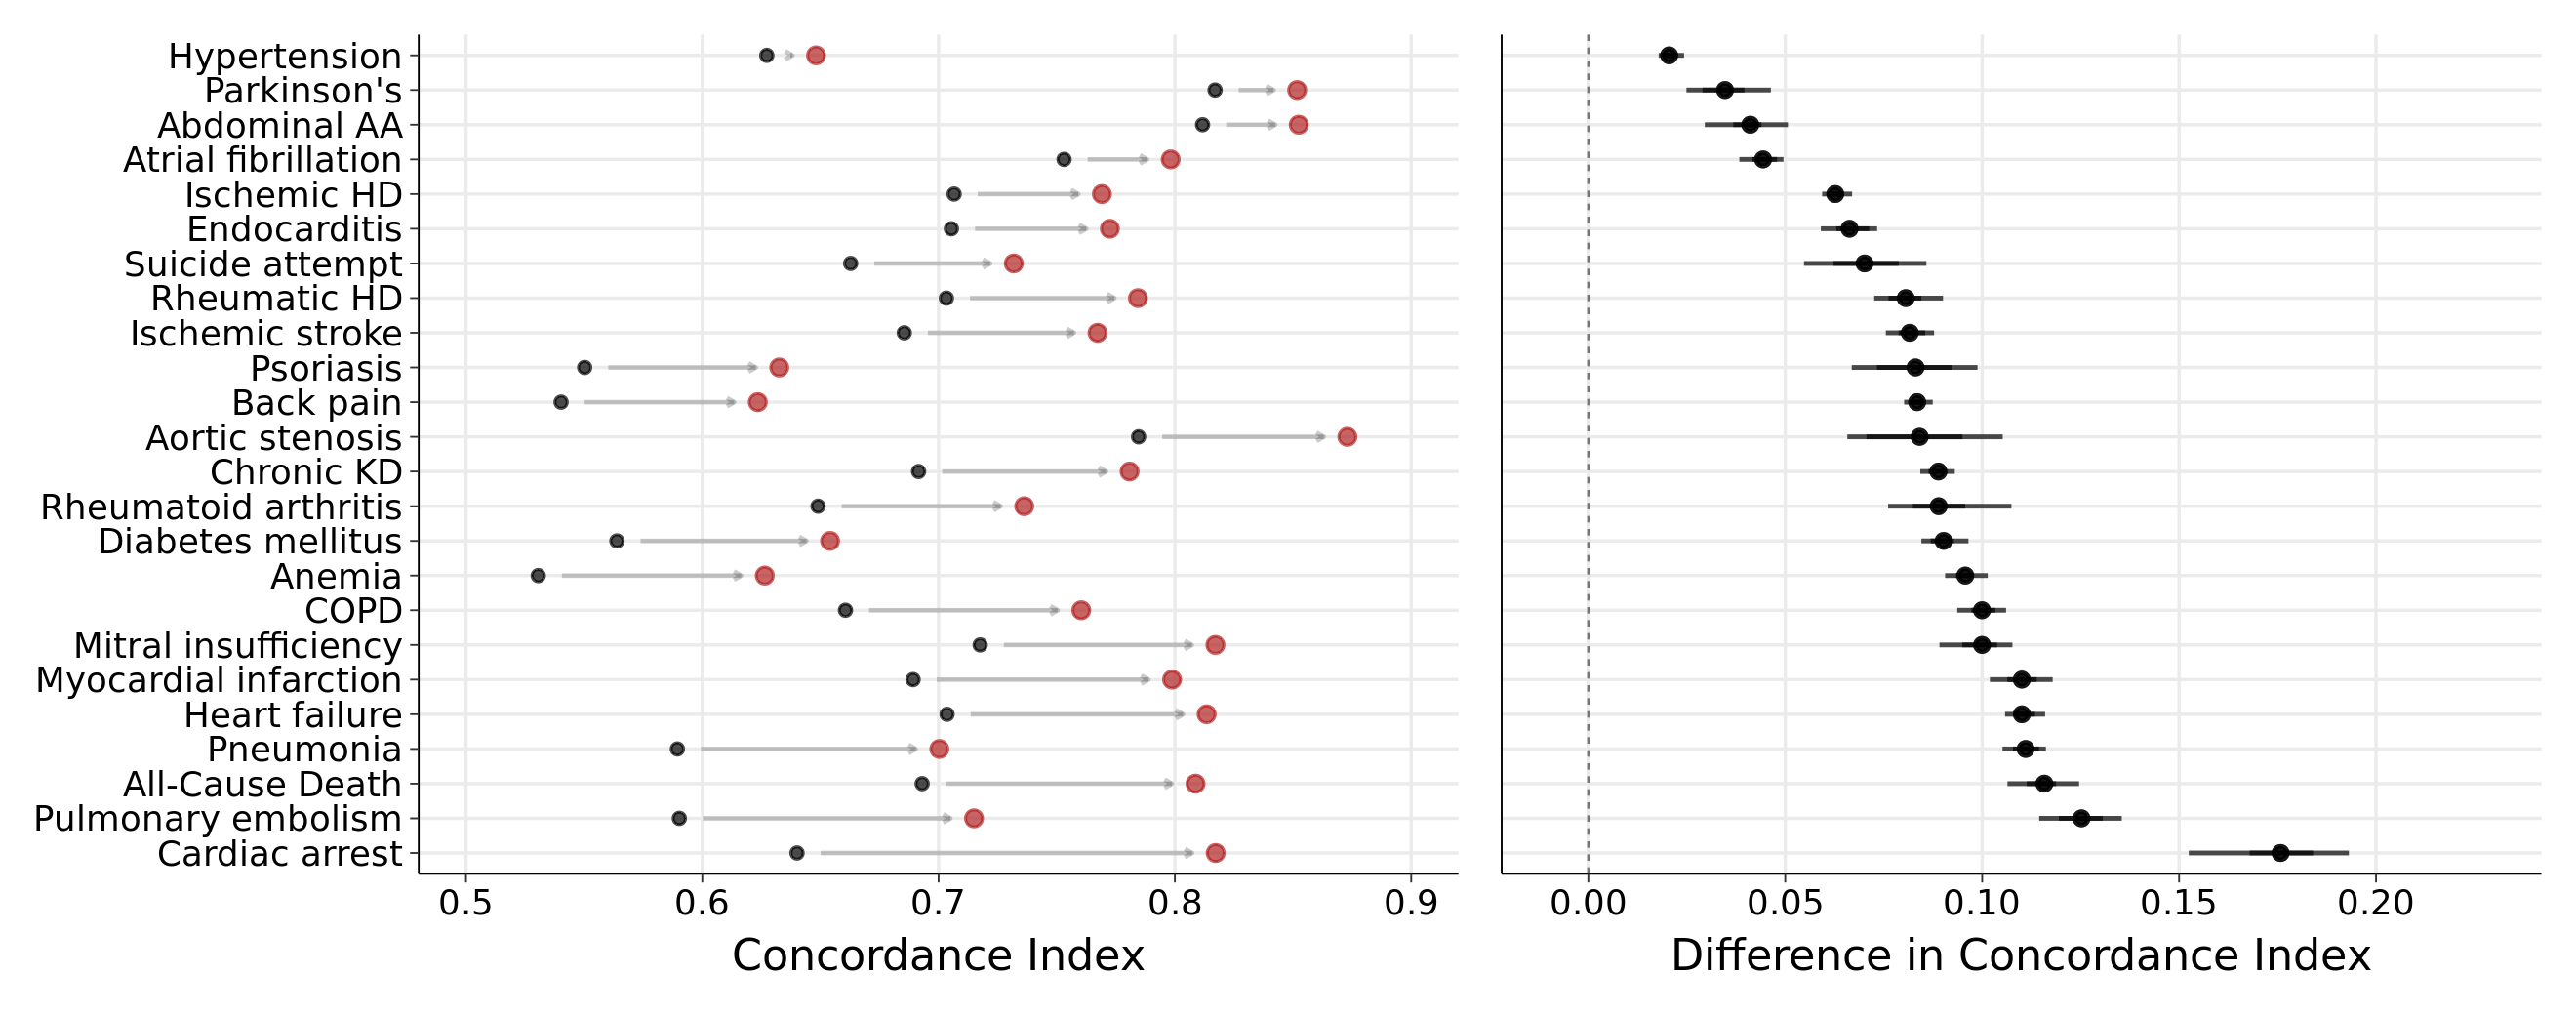

In [52]:
plot_width = 8.25; plot_height=3.25; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

fig5b = plot_against_score("AgeSex_AoUCPH", "AgeSex+MedicalHistory_UKBBParams")

plot_name = "Figure4fg_AoU_Subset"
fig5b

In [53]:
fig5b %>% ggsave(filename=glue("outputs/{plot_name}.png"), device="png", width=plot_width, height=plot_height, dpi=plot_res)
fig5b %>% ggsave(filename=glue("outputs/{plot_name}.pdf"), device="pdf", width=plot_width, height=plot_height, dpi=plot_res)